In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df_first = pd.read_excel("/Users/alanadams/Downloads/DS3 project/College Board finances 2007-2025_ (1).xlsx")

In [3]:
df_first

,year,#_of_ap_exams,exam_fee
0,2026,NaN,99
1,2025,6182171.0,99
2,2024,5744259.0,98
3,2023,5197601.0,97
4,2022,4762347.0,96
5,2021,4578302.0,95
6,2020,4751957.0,94
7,2019,5098815.0,94
8,2018,5090324.0,94
9,2017,4957931.0,94


In [4]:
df_first["#_of_ap_exams"] = df_first["#_of_ap_exams"].astype("Int64")

In [5]:
df_first

,year,#_of_ap_exams,exam_fee
0,2026,<NA>,99
1,2025,6182171,99
2,2024,5744259,98
3,2023,5197601,97
4,2022,4762347,96
5,2021,4578302,95
6,2020,4751957,94
7,2019,5098815,94
8,2018,5090324,94
9,2017,4957931,94


In [23]:
import pandas as pd

df = df_first.copy()

df = df.sort_values("year")
df = df[df["exam_fee"].notna()]


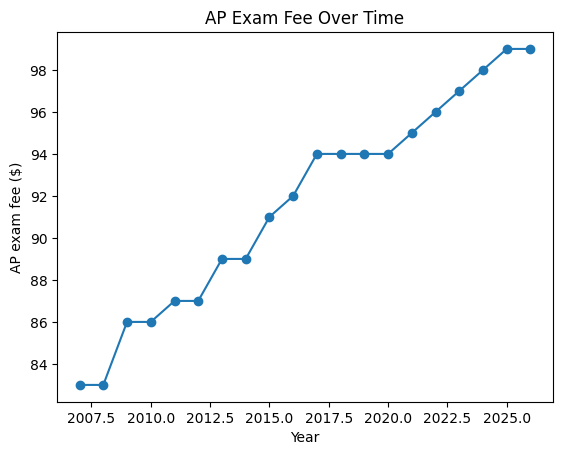

In [24]:
import matplotlib.pyplot as plt

plt.plot(df["year"], df["exam_fee"], marker="o")
plt.xlabel("Year")
plt.ylabel("AP exam fee ($)")
plt.title("AP Exam Fee Over Time")
plt.show()


In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df["year"].values.reshape(-1, 1)   # predictor
y = df["exam_fee"].values              # target

model = LinearRegression()
model.fit(X, y)

print("slope:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))


slope: 0.8578947368421056
intercept: -1638.2947368421057
R^2: 0.9777823341692562


In [26]:
%pip install scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
from sklearn.linear_model import LinearRegression
import numpy as np


In [28]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df["year"].values.reshape(-1, 1)   # predictor
y = df["exam_fee"].values              # target

model = LinearRegression()
model.fit(X, y)

print("slope:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))


slope: 0.8578947368421056
intercept: -1638.2947368421057
R^2: 0.9777823341692562


In [29]:
last_year = df["year"].max()
future_years = np.arange(last_year + 1, last_year + 11)  # next 10 years
future_X = future_years.reshape(-1, 1)

future_fees = model.predict(future_X)

future_df = pd.DataFrame({"year": future_years,
                          "predicted_exam_fee": future_fees.round(2)})
future_df


,year,predicted_exam_fee
0,2027,100.66
1,2028,101.52
2,2029,102.37
3,2030,103.23
4,2031,104.09
5,2032,104.95
6,2033,105.81
7,2034,106.66
8,2035,107.52
9,2036,108.38


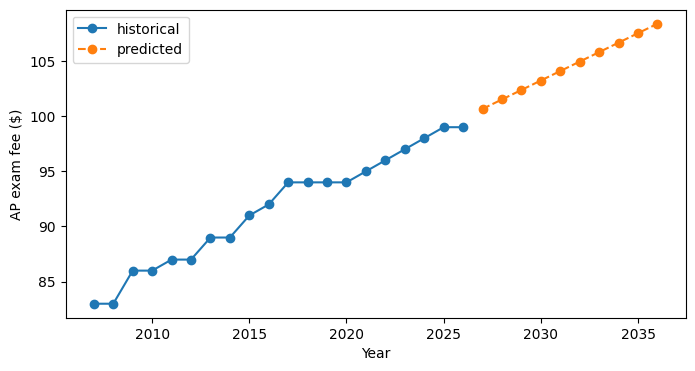

In [13]:
all_df = pd.concat([
    df[["year", "exam_fee"]].rename(columns={"exam_fee": "fee"}),
    future_df.rename(columns={"predicted_exam_fee": "fee"})
], ignore_index=True)

plt.figure(figsize=(8,4))
plt.plot(df["year"], df["exam_fee"], "o-", label="historical")
plt.plot(future_years, future_fees, "o--", label="predicted")
plt.xlabel("Year")
plt.ylabel("AP exam fee ($)")
plt.legend()
plt.show()


In [14]:
%pip install cpi



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np

df = df_first.copy()
df = df.sort_values("year")
df = df[df["exam_fee"].notna()]  # drop NaN fee row

# approximate CPI index, base year 2024 = 1.00
inflation_index = {
    2007: 0.80,
    2008: 0.83,
    2009: 0.84,
    2010: 0.86,
    2011: 0.89,
    2012: 0.91,
    2013: 0.93,
    2014: 0.95,
    2015: 0.96,
    2016: 0.97,
    2017: 0.98,
    2018: 0.99,
    2019: 1.00,
    2020: 1.01,
    2021: 1.03,
    2022: 1.07,
    2023: 1.10,
    2024: 1.12,
    2025: 1.14,
    2026: 1.17,
}

base_year = 2024
base_index = inflation_index[base_year]

df["inflation_factor_to_2024"] = df["year"].map(
    lambda y: base_index / inflation_index[int(y)]
)

df["exam_fee_real_2024"] = (df["exam_fee"] * df["inflation_factor_to_2024"]).round(2)
df[["year", "exam_fee", "exam_fee_real_2024"]].head()


,year,exam_fee,exam_fee_real_2024
19,2007,83,116.20
18,2008,83,112.00
17,2009,86,114.67
16,2010,86,112.00
15,2011,87,109.48


In [16]:
from sklearn.linear_model import LinearRegression

X = df["year"].values.reshape(-1, 1)
y = df["exam_fee_real_2024"].values

model = LinearRegression()
model.fit(X, y)

print("slope (real $ per year):", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))


slope (real $ per year): -0.9247744360902259
intercept: 1970.3981503759405
R^2: 0.9083486172742119


In [17]:
last_year = df["year"].max()  # should be 2026
future_years = np.arange(last_year + 1, last_year + 6)  # 2027–2031
future_X = future_years.reshape(-1, 1)

future_fees_real_2024 = model.predict(future_X)

future_df = pd.DataFrame({
    "year": future_years,
    "predicted_exam_fee_real_2024": future_fees_real_2024.round(2)
})
future_df


,year,predicted_exam_fee_real_2024
0,2027,95.88
1,2028,94.96
2,2029,94.03
3,2030,93.11
4,2031,92.18


In [18]:
#test

   year  predicted_exam_fee  real_fee_2026_dollars
0  2027              100.66                  98.69
1  2028              101.52                  97.58
2  2029              102.37                  96.47
3  2030              103.23                  95.37
4  2031              104.09                  94.28
5  2032              104.95                  93.19
6  2033              105.81                  92.11
7  2034              106.66                  91.03
8  2035              107.52                  89.97
9  2036              108.38                  88.91


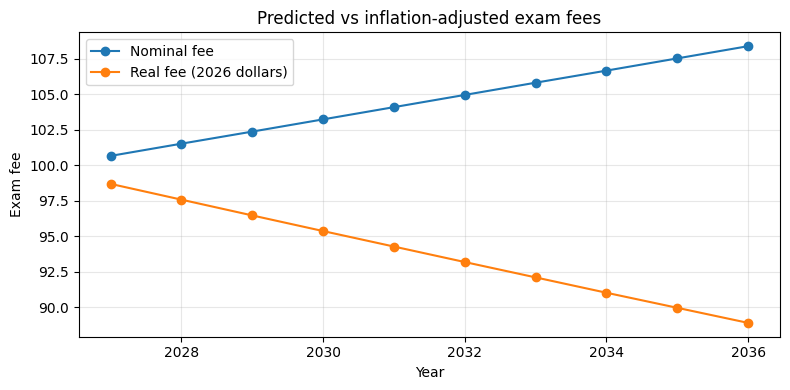

In [19]:
# Assumes you already did:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# ---- Input data: nominal predicted fees ----
years = np.arange(2027, 2037)  # 2027–2036 inclusive
predicted_exam_fee = np.array([
    100.66,
    101.52,
    102.37,
    103.23,
    104.09,
    104.95,
    105.81,
    106.66,
    107.52,
    108.38
])

# ---- Parameters for inflation adjustment ----
base_year = 2026
inflation_rate = 0.02  # 2% per year

# Years since base year for each prediction
years_since_base = years - base_year

# Real (inflation-adjusted to base_year dollars) fees
real_fee_2026_dollars = predicted_exam_fee / (1 + inflation_rate) ** years_since_base

# ---- Build dataframe ----
df = pd.DataFrame({
    "year": years,
    "predicted_exam_fee": predicted_exam_fee.round(2),
    "real_fee_2026_dollars": real_fee_2026_dollars.round(2)
})

print(df)

# Optional: quick plot
plt.figure(figsize=(8, 4))
plt.plot(df["year"], df["predicted_exam_fee"], marker="o", label="Nominal fee")
plt.plot(df["year"], df["real_fee_2026_dollars"], marker="o", label="Real fee (2026 dollars)")
plt.xlabel("Year")
plt.ylabel("Exam fee")
plt.title("Predicted vs inflation-adjusted exam fees")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
